# FITTING NOTEBOOK - NIRSpec

In [3]:
# ALWAYS RUN THE FIRST THREE CELLS
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import corner
import transitspectroscopy as ts
from tqdm import tqdm
import pandas as pd

import seaborn as sns
sns.set_style('ticks')

In [5]:
# Open data file (transitspectroscopy output)
path = '/media/peng/KINGSTON/'
with open(path + '_jw03385002001_toi1130_nrs1_spectrum.pkl', 'rb') as file:
    data = pickle.load(file)

# NIRSpec
# data is a dict with 7 entries: 
# 1. metadata: Information about instrument and detector, ex. name: NIRSpec, detector: NRS1
# 2. & 3. tso & tso_err: Not sure, just a bunch of zeroes as far as I can see
# 4. traces: Contains times in random order, x, ycorrected, ysmoothed
# 5 spectra: Contains times in increasing order, original + original_err, corrected + corrected_err, wavelength map (a bunch of nans) and wavelengths that the detector measures
# --> IMPORTANT: data['spectra']['corrected'] and corrected_err contain each spectroscopic lc for the corresponding wavelength in ppm (more detail in next section)
# 6 & 7. whitelight & whitelight_err: Relative flux for white light curve and its errorbars

In [6]:
# Define planetary parameters
per = 4.074554             # Period (Days)
t0 = 2460543.0635          # Mid-Transit Time (BJD)
a = 13.77                  # Semimajor Axis (a/R*)
b = -0.518                 # Impact Parameter
ecc = 0.052162             # Eccentricity
omega = 141.11             # Argument of Periastron (Degrees)

# Define planet and instrument name
star = 'TOI-1130'
pn = 'TOI-1130b'
itm = 'NRS1'

# White Light Curves

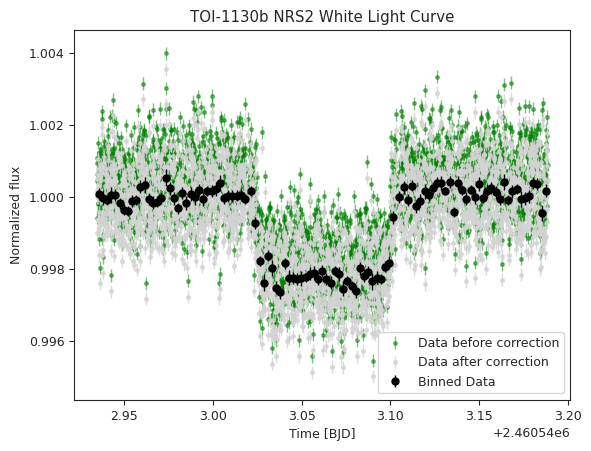

In [5]:
# Define time and flux data points - white light curves
t = data['spectra']['times']
f_wl = data['whitelight']
ferr_wl = data['whitelight_err']

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'g', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data before correction', zorder = 1)

# Normalize flux such that the out-of-transit flux = 1
f_med = np.nanmedian(f_wl[:100])
f_wl, ferr_wl = f_wl / f_med, ferr_wl / f_med
tbin, fbin, ferrbin = juliet.bin_data(t, f_wl, 25)

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.8, label = 'Data after correction', zorder = 5)
plt.errorbar(tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 10)

plt.title(pn+' '+itm+ ' White Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized flux')

# Define root-mean-squared values
rms = ts.utils.get_mad_sigma(np.median(f_wl[: 100] - 1.), f_wl[: 100] - 1.) * 1e6
rms_predicted = np.median(ferr_wl[: 100]) * 1e6

plt.legend()
plt.show()

In [6]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

In [7]:
# Define parameters - comment out all sets except for one

# # Just transit
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.]]
# #--------------------------------------------------------------------------------------------------

# Linear
params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
          'theta0_'+itm]

dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform']

hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
          [-10, 10]]
# #--------------------------------------------------------------------------------------------------

# # GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [1e-8, 1e2], [1e-8, 1e3]]
#--------------------------------------------------------------------------------------------------

# Linear + GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'theta0_'+itm, 'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'uniform', 'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [-10, 10], [1e-6, 1e6], [1e-3, 1e3]]


priors = juliet.generate_priors(params, dists, hyperps) 

In [8]:
# Put data into dictionaries to feed into juliet
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_wl, ferr_wl
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler, again comment out everything except for the one you're running

# # Just transit
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit')
# #---------------------------------------------------------------------------------------------

# Linear
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear')
# #---------------------------------------------------------------------------------------------

# # GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_GP')
#---------------------------------------------------------------------------------------------

# # Linear + GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  linear_regressors_lc = linear_regressors, GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear+GP')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_NRS2_wlcfit_linear/_dynesty_DNS_posteriors.pkl
done


In [9]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_wl**2)

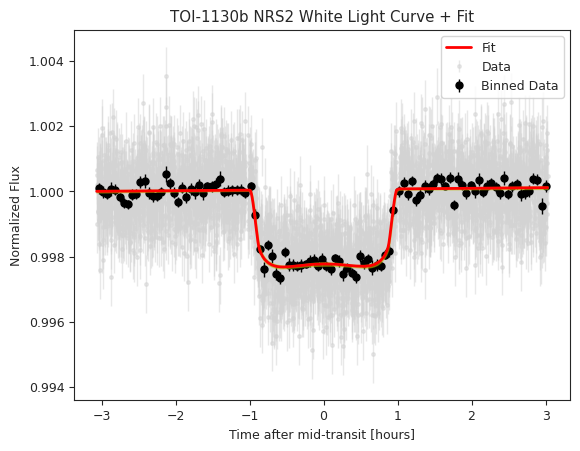

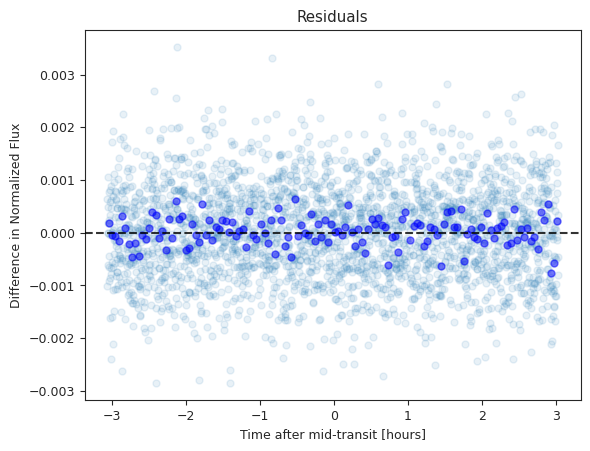

In [10]:
# Normalize time so that it's relative to best-fit mid-transit and make some plots
mid_t = np.nanmedian(results.posteriors['posterior_samples']['t0_p1'])
norm_t = (t - mid_t) * 24
norm_tbin = (tbin - mid_t) * 24

# Scatter data
plt.errorbar(norm_t, f_wl, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+' '+itm+ ' White Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear/'+itm+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_wl - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear/'+itm+'_residuals.png')
plt.show()

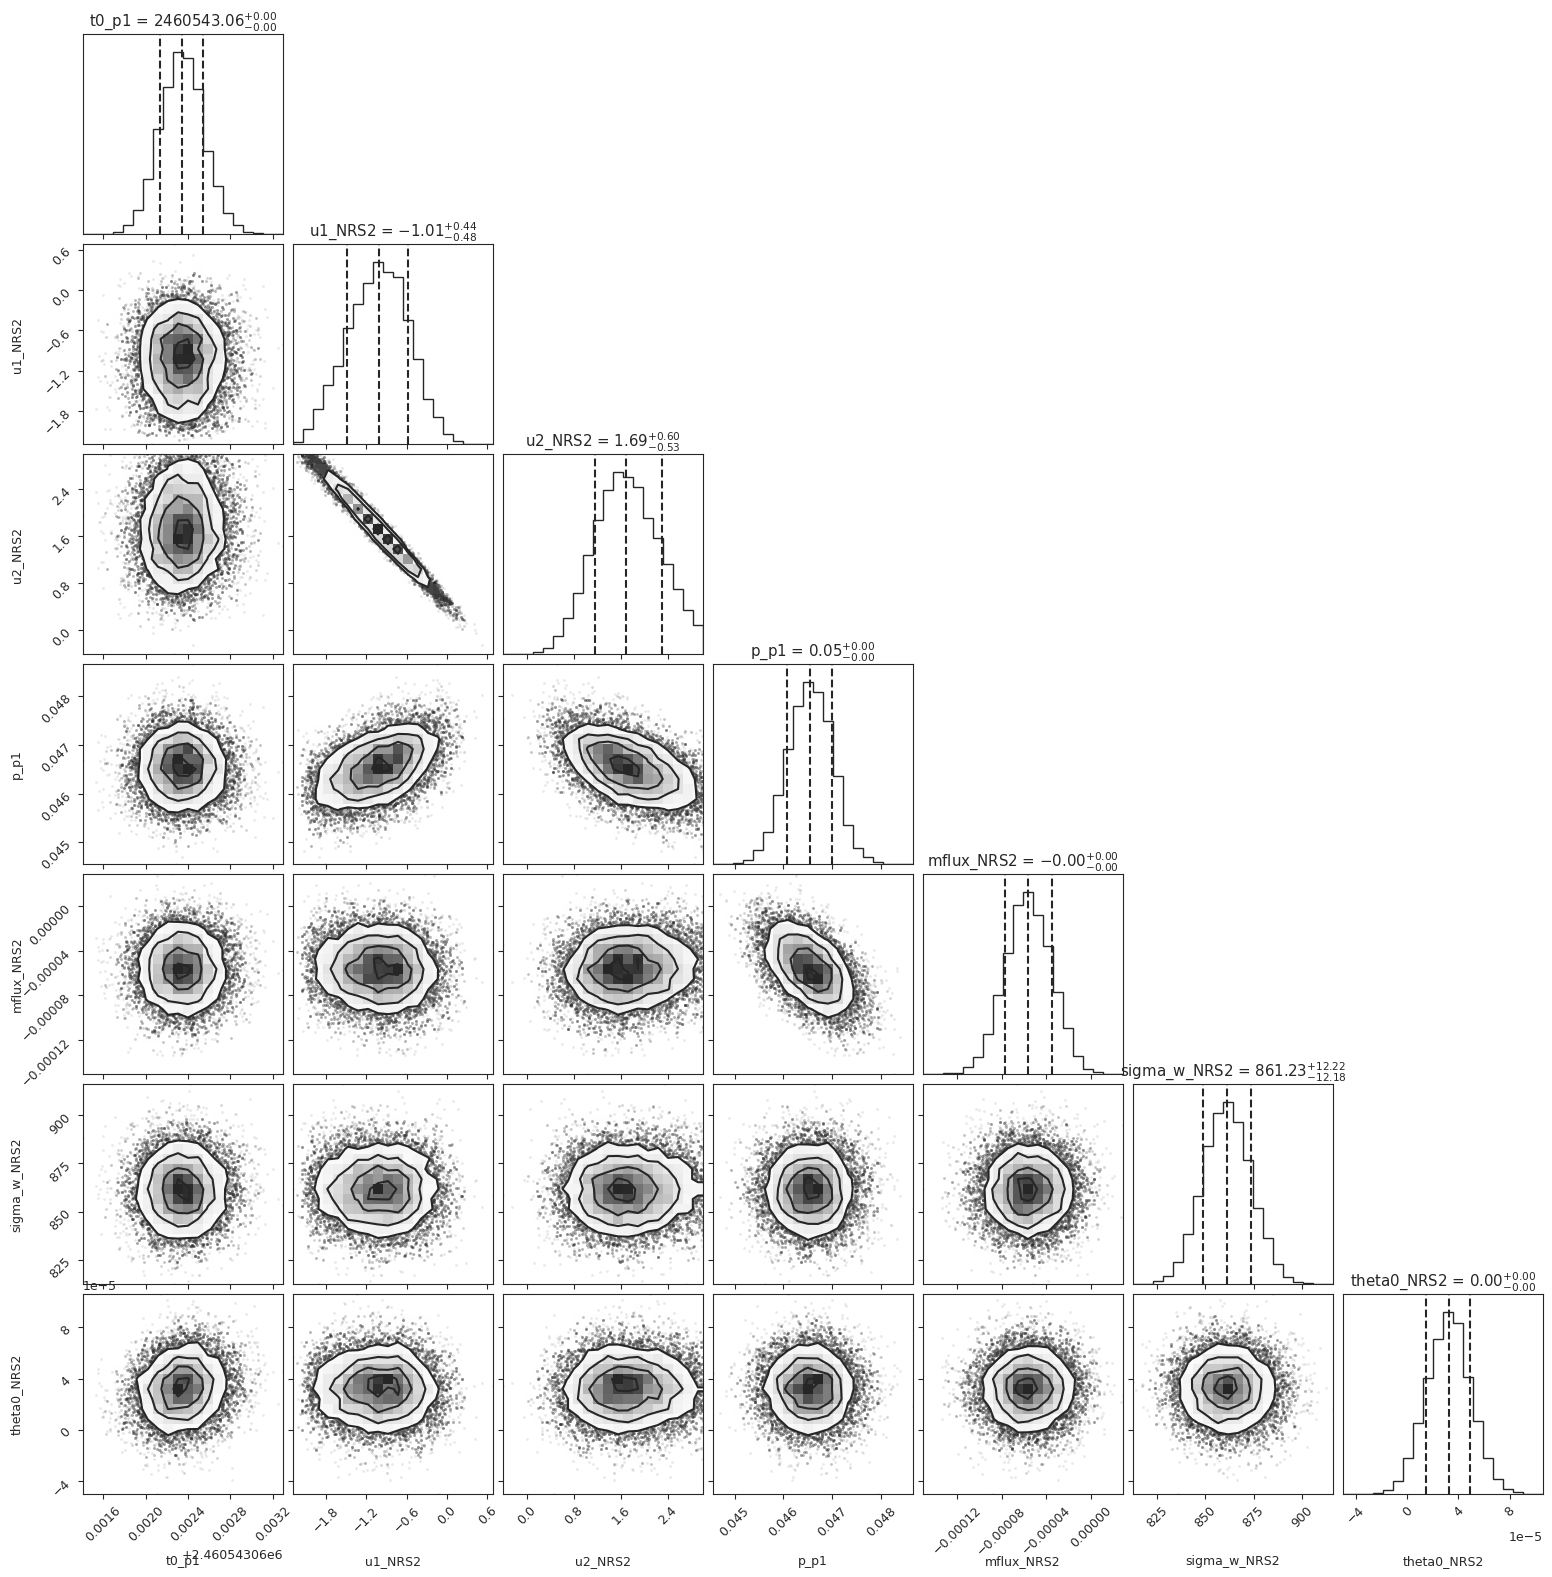

In [11]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles = True, quantiles = [0.16, 0.50, 0.84])
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear/'+itm+'_corner.png')
plt.show()

In [12]:
# Print log evidence, lnZ
# print('Without linear or GP:', results.posteriors['lnZ'])
print('With linear only:', results.posteriors['lnZ'])
# print('With GP only:', results.posteriors['lnZ'])
# print('With linear + GP:', results.posteriors['lnZ'])

With linear only: 14972.623838445552


In [13]:
# Get transit depth for white light curve
td_list = (results.posteriors['posterior_samples']['p_p1']**2) * 100

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Transit Depth:', td, '\n', 
      'Errors:', tderr)

Transit Depth: 0.2166471182659463 
 Errors: 0.004233196717110537


# Spectroscopic Light Curves

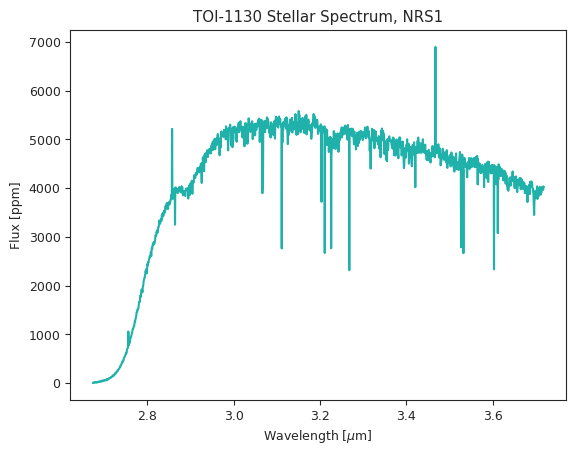

In [7]:
spectra = data['spectra']

# There are m times and n wavelengths
t = spectra['times']
wl = spectra['wavelengths']   

# Each spectra['corrected'] is a mxn array, where columns contain the corresponding spectroscopic light curve in ppm
slc, slcerr = spectra['corrected'], spectra['corrected_err']  

# We can plot corrected spectrum vs wavelength to see something that looks like the stellar spectrum
plt.plot(wl, slc[0], color = 'lightseagreen')
plt.title(star+' Stellar Spectrum, '+itm)
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Flux [ppm]')
plt.show()

# To format slc and slcerr to give fluxes at each wavelength, index them along a column
# For example f[i] = slc[:, i] gives the ith spectroscopic light curve corresponding to the ith wavelength

In [8]:
# Store all spectroscopic light curves in a dict, where each key is a wavelength whose value is another dict. In the nested dict, keys will be flux and flux error 
# --> spec_lcs = {wavelength 1: {flux: [...], err: [...]}, wavelength 2: {flux: [...], err: [...]}, ..., wavelength n: {flux: [...], err: [...]}}
spec_lcs = {}
for i in range(len(wl)):
    wavelength = wl[i]

    # Normalize each light curve 
    slc_med = np.nanmedian(slc[:, i][:100])
    spec_lcs[wavelength] = {}
    spec_lcs[wavelength]['f'] = slc[:, i] / slc_med
    spec_lcs[wavelength]['ferr'] = slcerr[:, i] / slc_med

# for i in spec_lcs:
#     print(i)

In [3]:
# Bin light curves since spec_lcs has spectroscopic light curves in instrument's native resolution
bin_slc = {}
for i in range(0, len(wl) - 20, 20):
    wl_mean = np.round(np.mean(wl[i: i+20]), 7)  # This is just to name the bin
    
    bin_slc[wl_mean] = {}
    bin_slc[wl_mean]['f'] = 0
    bin_slc[wl_mean]['ferr'] = 0

    # Add every 10 spectroscopic light curves together, then normalize flux to 1
    for j in wl[i: i+20]:
        bin_slc[wl_mean]['f'] += spec_lcs[j]['f']
        bin_slc[wl_mean]['ferr'] += spec_lcs[j]['ferr']

    fbin_med = np.nanmedian(bin_slc[wl_mean]['f'][:100])
    bin_slc[wl_mean]['f'] = bin_slc[wl_mean]['f'] / fbin_med
    bin_slc[wl_mean]['ferr'] = bin_slc[wl_mean]['ferr'] / fbin_med

# Run this to see all binned wavelengths
# for i in bin_slc:
#     print(i)

2.6808364
2.6944183
2.7079994
2.7216265
2.7352176
2.748796
2.7623735
2.7759853
2.7895844
2.8031589
2.8167323
2.8303194
2.8439349
2.857505
2.8710739
2.8846415
2.8982406
2.9118325
2.9253964
2.9389589
2.9525202
2.9661098
2.9796981
2.9932552
3.0068108
3.020365
3.0339177
3.0475256
3.0610783
3.0746264
3.0881729
3.1017178
3.1152611
3.1288418
3.1424028
3.1559411
3.1694778
3.1830127
3.1965458
3.2100772
3.2236248
3.2371949
3.2507209
3.264245
3.2777673
3.2912877
3.3048062
3.3183228
3.3318374
3.3453684
3.3589216
3.3724304
3.3859372
3.399442
3.4129448
3.4264455
3.4399441
3.4534407
3.4669351
3.4804275
3.4939177
3.5074058
3.5208918
3.5344276
3.5479184
3.5613979
3.5748751
3.5883501
3.6018229
3.6152934
3.6287616
3.6422275
3.6556912
3.6691526
3.6826116
3.6960683
3.7095226


In [8]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

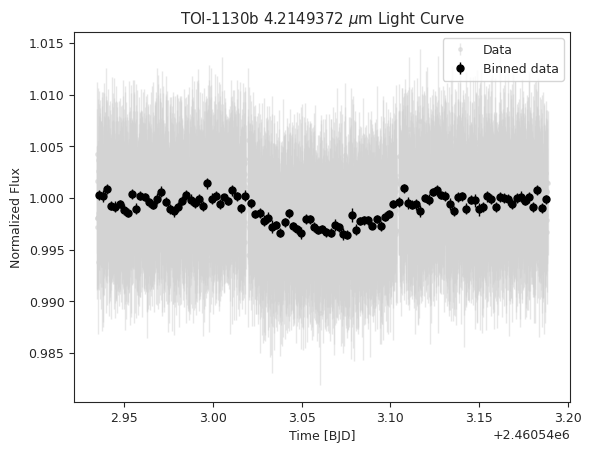

In [9]:
# Define time and flux data points - spectroscopic light curves

trial_list = [3.8534895, 3.9474171, 4.0612377, 4.2149372, 4.4014793, 4.4745839, 4.6204934, 4.8121505, 4.9569554, 5.1012321]

trial_wl = trial_list[3]
t = t     # Sorry I just feel like defining time again for the billionth time

# Uncomment to use native resolution
# f_s = spec_lcs[trial_wl]['f']
# ferr_s = spec_lcs[trial_wl]['ferr']

# Uncomment to use bin_slc
f_s = bin_slc[trial_wl]['f']
ferr_s = bin_slc[trial_wl]['ferr']

# Don't need to normalize since it's already normalized in the dict, so just bin
tbin, fsbin, ferrsbin = juliet.bin_data(t, f_s, 25)

plt.errorbar(t, f_s, yerr = ferr_s, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data', zorder = 1)
plt.errorbar(tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned data', zorder = 10)
plt.title(pn+' '+str(round(trial_wl, 7))+' $\mu$m Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized Flux')
plt.legend()

plt.show()

In [10]:
# For now, only define parameters + linear model for NRS1 and 2
# t0 = 2460543.0631091068 # for NRS1
t0 = 2460543.0623039217 # for NRS2

u1 = -1.0117974286 # for NRS2
u2 = 1.6939836238


params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
          'theta0_'+itm]

dists = ['fixed', 'fixed', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform']

hyperps = [per, t0, a, b, [-3, 3], [-3, 3], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
          [-10, 10]]

priors = juliet.generate_priors(params, dists, hyperps)

# Put data into dictionaries
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_s, ferr_s
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+str(round(trial_wl, 7))+'_fit')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_4.2149372_fit/_dynesty_DNS_posteriors.pkl
done


In [11]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_s**2)

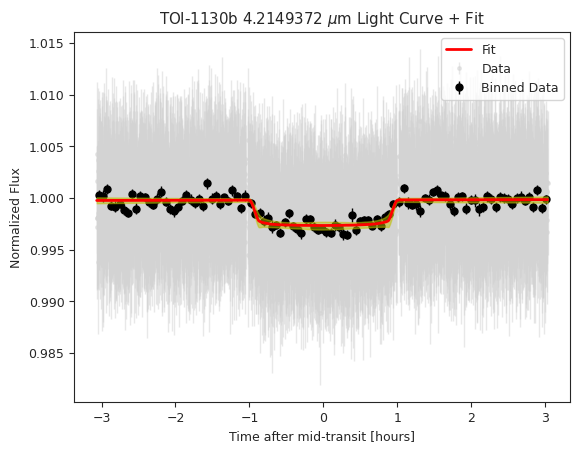

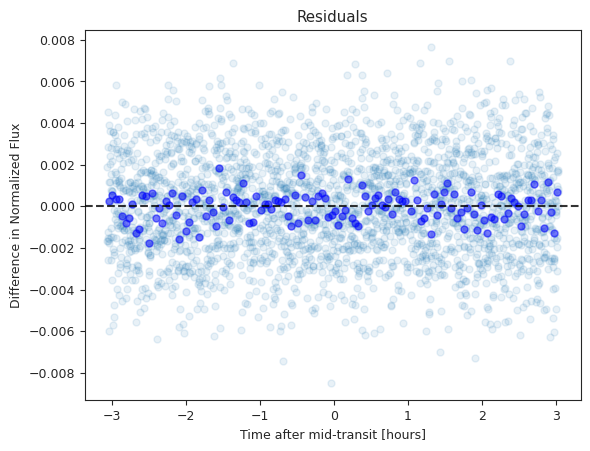

In [13]:
# Normalize time so it's relative to mid-transit
norm_t = (t - t0) * 24
norm_tbin = (tbin - t0) * 24

# Scatter data
plt.errorbar(norm_t, f_s, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+ ' '+str(round(trial_wl, 7))+ ' $\mu$m Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_s - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_residuals.png')
plt.show()

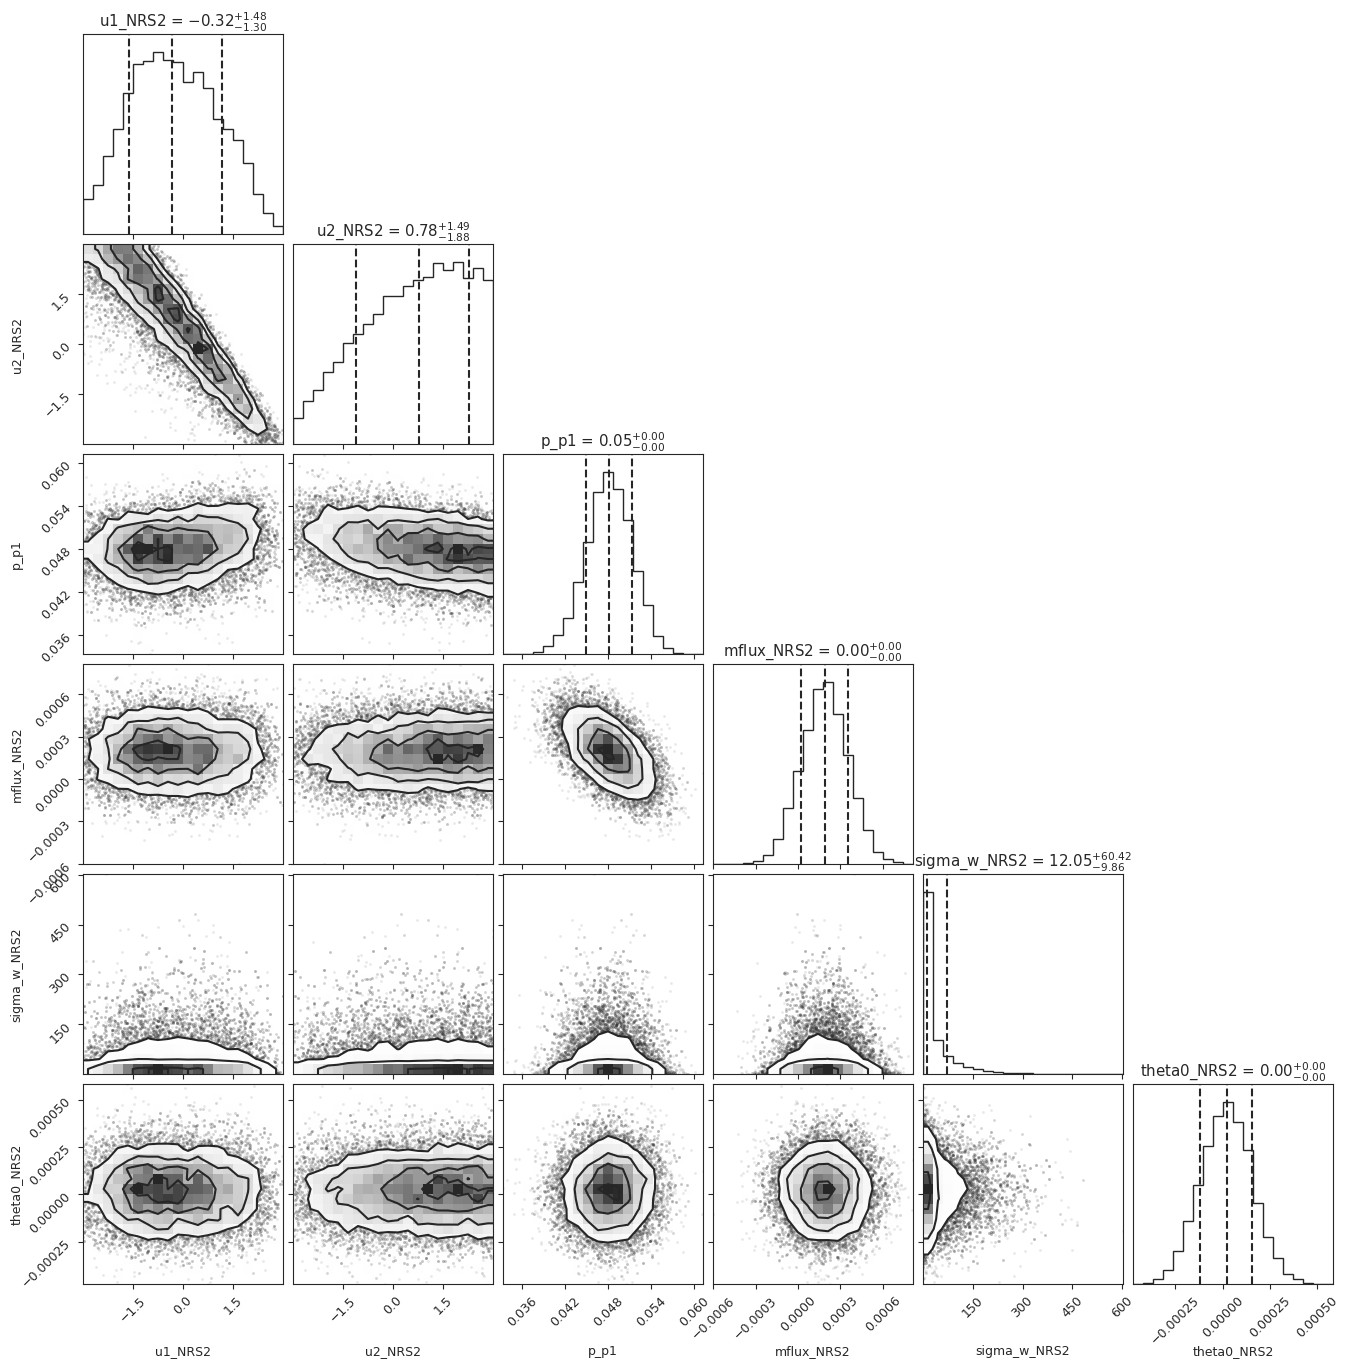

Log Evidence: 10641.581722908368


In [14]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles = True, quantiles = [0.16, 0.50, 0.84])
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_corner.png')
plt.show()

print('Log Evidence:', results.posteriors['lnZ'])

In [15]:
# Get best fit value of p_p1 and convert to transit depth
td_list = (results.posteriors['posterior_samples']['p_p1']**2)

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Wavelength:', trial_wl, '\n',
      'Transit Depth:', td, '\n', 
      'Errors:', tderr)

Wavelength: 4.2149372 
 Transit Depth: 0.0023166557020080553 
 Errors: 0.0003105304934965096


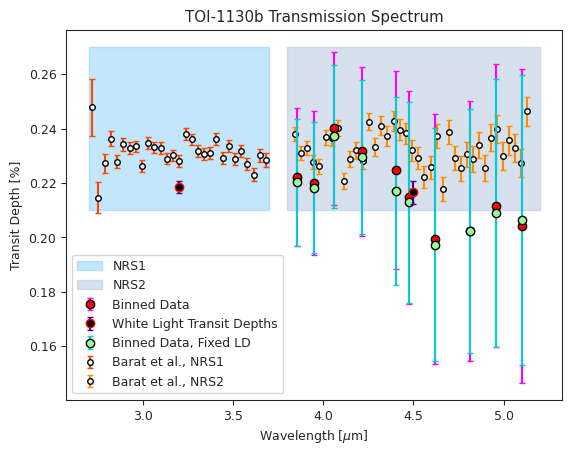

In [34]:
# Load spectrum from Barat et al., 2026 for comparison
barat_nrs1 = pd.read_csv('barat_toi1130b_spectrum_nrs1.csv')
barat_wl_nrs1 = barat_nrs1['CENTRALWAVELNG']
barat_td_nrs1 = barat_nrs1['PL_TRANDEP']
barat_tderr_nrs1 = barat_nrs1['PL_TRANDEPERR1']

barat_nrs2 = pd.read_csv('barat_toi1130b_spectrum_nrs2.csv')
barat_wl_nrs2 = barat_nrs2['CENTRALWAVELNG']
barat_td_nrs2 = barat_nrs2['PL_TRANDEP']
barat_tderr_nrs2 = barat_nrs2['PL_TRANDEPERR1']

# Plot wavlength ranges for each detector
nrs1, nrs2 = [2.7, 3.7], [3.8, 5.2]
ys = [0.21, 0.27]   # This also indirectly sets the ylim
plt.fill_betweenx(ys, nrs1[0], nrs1[1], color = 'lightskyblue', alpha = 0.5, zorder = 1, label = 'NRS1')
plt.fill_betweenx(ys, nrs2[0], nrs2[1], color = 'lightsteelblue', alpha = 0.5, zorder = 1, label = 'NRS2')

# Plot some points from binned spectrum
samp_binx = [3.8534895, 3.9474171, 4.0612377, 4.2149372, 4.4014793, 
             4.4745839, 4.6204934, 4.8121505, 4.9569554, 5.1012321]

samp_biny = [0.22214841343924646, 0.22001902550597904, 0.24001337905631398, 0.23166557020080553, 0.22465087207097267, 
             0.2147922378845888, 0.1993858534306896, 0.20247658436546118, 0.2116532668091944, 0.20415767948566071]
samp_binyerr = [0.02521946712950558, 0.026416226324575336, 0.02812966233885033, 0.031053049349650964, 0.036357240035630796, 
                0.03918173592468118, 0.04579794987284287, 0.047795810030054425, 0.05206581364129727, 0.05770449917693704]

plt.errorbar(samp_binx, samp_biny, yerr = samp_binyerr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'r', mec = 'k', color = 'fuchsia', label = 'Binned Data', zorder = 8)

# Plot transit depths from white light curves
central_bins = [3.2, 4.5]
central_td = [0.2184226235891346, 0.2166471182659463]
central_tderr = [0.0021033446739131805, 0.004233196717110537]

plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'k', mec = 'r', color = 'indigo', label = 'White Light Transit Depths', zorder = 10)

# Fixed LD coefficients
samp_fixbiny = [0.22016206777721153, 0.2182898815227043, 0.23709611191407906, 0.22946703436783036, 0.21697942018210323,
                0.2128179045341805, 0.19730546086273842, 0.20232942305857685, 0.20885710179776068, 0.20631020630873237]
samp_fixbinyerr = [0.023237872430005635, 0.024179853598058406, 0.026426039722674502, 0.028308064614335923, 0.03453711239626043, 
                   0.03687056571979706, 0.04290064039583867, 0.04476680219001171, 0.04922027238804577, 0.05318330053545818]

plt.errorbar(samp_binx, samp_fixbiny, yerr = samp_fixbinyerr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'palegreen', mec = 'k', color = 'darkturquoise', label = 'Binned Data, Fixed LD', zorder = 8)

plt.errorbar(barat_wl_nrs1, barat_td_nrs1, yerr = barat_tderr_nrs1, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al., NRS1', zorder = 1)
plt.errorbar(barat_wl_nrs2, barat_td_nrs2, yerr = barat_tderr_nrs2, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'darkorange', label = 'Barat et al., NRS2', zorder = 1)

plt.title(pn+' Transmission Spectrum')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')
# plt.ylim(0.20, 0.26)
plt.legend()
plt.show()

In [ ]:
# Run speclc_fit.py which loops through all indices of spec_lcs or any similar dict and fits each light curve
%run nirspec_speclc_fit.py

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.6808364_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.6944183_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7079994_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7216265_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7352176_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.748796_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7623735_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7759853_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extract

13160it [01:26, 139.14it/s, batch: 0 | bound: 10 | nc: 26 | ncall: 285416 | eff(%):  4.595 | loglstar:   -inf < 11087.811 <    inf | logz: 11068.969 +/-  0.134 | dlogz: 456.988 >  0.010]     

NameError: name 'pn' is not defined

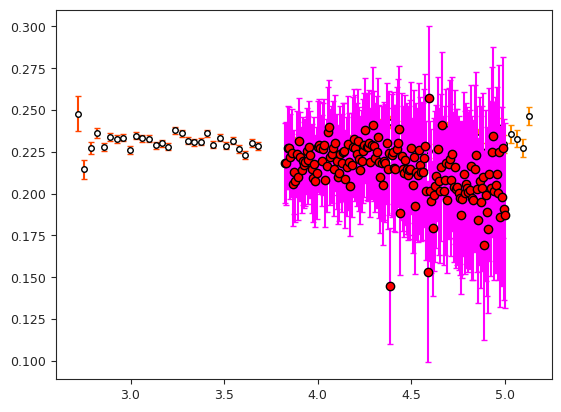

In [2]:
# Load spectrum from Barat et al., 2026 for comparison
barat_nrs1 = pd.read_csv('barat_toi1130b_spectrum_nrs1.csv')
barat_wl_nrs1 = barat_nrs1['CENTRALWAVELNG']
barat_td_nrs1 = barat_nrs1['PL_TRANDEP']
barat_tderr_nrs1 = barat_nrs1['PL_TRANDEPERR1']

barat_nrs2 = pd.read_csv('barat_toi1130b_spectrum_nrs2.csv')
barat_wl_nrs2 = barat_nrs2['CENTRALWAVELNG']
barat_td_nrs2 = barat_nrs2['PL_TRANDEP']
barat_tderr_nrs2 = barat_nrs2['PL_TRANDEPERR1']

first_72 = pd.read_csv('TOI-1130b_NRS2.csv')
first_wl = first_72['wavelength']
first_td = first_72['transit depth']
first_tderr = first_72['transit depth error']

plt.errorbar(first_wl, first_td, yerr = first_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'r', mec = 'k', color = 'fuchsia', label = 'Binned Data', zorder = 10)
plt.errorbar(barat_wl_nrs1, barat_td_nrs1, yerr = barat_tderr_nrs1, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al., NRS1', zorder = 1)
plt.errorbar(barat_wl_nrs2, barat_td_nrs2, yerr = barat_tderr_nrs2, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'darkorange', label = 'Barat et al., NRS2', zorder = 1)

plt.title(pn+' Transmission Spectrum')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')
plt.xlim(3.8, 5.2)
# plt.ylim(0.20, 0.26)
plt.legend()
plt.show()